In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
# note you need to download edm code from https://github.com/NVlabs/edm and add it to your path.
sys.path.append("/n/home12/binxuwang/Github/edm")

In [1]:
import os
from os.path import join
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm, trange
import pickle   
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
import os
import urllib.request
def download_edm_model(dataset_name, ckpt_dir):
    ckpt_url = {"cifar32": "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl",
                "ffhq64": "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-ffhq-64x64-uncond-vp.pkl",
                "afhq64": "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-afhqv2-64x64-uncond-vp.pkl"}[dataset_name]
    ckpt_filename = os.path.join(ckpt_dir, os.path.basename(ckpt_url))
    if not os.path.exists(ckpt_filename):
        urllib.request.urlretrieve(ckpt_url, ckpt_filename)
        print(f"Downloaded EDM model file {ckpt_filename}")
    else:
        print(f"EDM model file {ckpt_filename} already exists, skipping download")
    return ckpt_filename

In [82]:
def edm_sampler_return(
    net, latents, class_labels=None, randn_like=torch.randn_like,
    num_steps=18, sigma_min=0.002, sigma_max=80, rho=7,
    S_churn=0, S_min=0, S_max=float('inf'), S_noise=1,
):
    """
    Heun's Sampling function from EDM, adapted to return the trajectory of x_t and denoised x_t
    """
    # Adjust noise levels based on what's supported by the network.
    sigma_min = max(sigma_min, net.sigma_min)
    sigma_max = min(sigma_max, net.sigma_max)

    # Time step discretization.
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=latents.device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([net.round_sigma(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0

    # Main sampling loop.
    x_traj = []
    denoised_traj = []
    x_next = latents.to(torch.float64) * t_steps[0]
    x_traj.append(x_next.detach().clone())
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])): # 0, ..., N-1
        x_cur = x_next

        # Increase noise temporarily.
        gamma = min(S_churn / num_steps, math.sqrt(2) - 1) if S_min <= t_cur <= S_max else 0
        t_hat = net.round_sigma(t_cur + gamma * t_cur)
        x_hat = x_cur + (t_hat ** 2 - t_cur ** 2).sqrt() * S_noise * randn_like(x_cur)

        # Euler step.
        denoised = net(x_hat, t_hat, class_labels).to(torch.float64)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur
        # Apply 2nd order correction.
        if i < num_steps - 1:
            denoised = net(x_next, t_next, class_labels).to(torch.float64)
            d_prime = (x_next - denoised) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)

        x_traj.append(x_next.detach().clone())
        denoised_traj.append(denoised.detach().clone())
    x_traj = torch.stack(x_traj, dim=0)
    denoised_traj = torch.stack(denoised_traj, dim=0)
    return x_next, t_steps, x_traj, denoised_traj



In [26]:
def tsr_to_mtg(tsr, nrow=8, padding=2):
    images_actual = (tsr * 127.5 + 128).clip(0, 255).to(torch.uint8)
    return ToPILImage()(make_grid(images_actual, nrow=nrow, padding=padding))

In [13]:
import torchvision
import torchvision.transforms as transforms
CIFAR10_DIR = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets"
# Load the whole CIFAR-10 dataset into a tensor and flatten as a matrix

norm_mean, norm_std = 0.5, 0.5
denormalize = transforms.Normalize(mean=-norm_mean / norm_std, std=1/norm_std)
cifar10_dataset = torchvision.datasets.CIFAR10(
    root=CIFAR10_DIR, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ])
)
cifar10_loader = torch.utils.data.DataLoader(
    cifar10_dataset, batch_size=len(cifar10_dataset),
    shuffle=False, num_workers=8
)
# Load all images into a single tensor
cifar10_images, cifar10_labels = next(iter(cifar10_loader))
# Flatten: [N, C, H, W] -> [N, C*H*W]
cifar10_mat = cifar10_images.view(cifar10_images.size(0), -1)

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cov_mat = torch.cov(cifar10_mat.to(device).T)
cov_eigs, eigvecs = torch.linalg.eigh(cov_mat)
imgmean = cifar10_mat.mean(dim=0)

imgmean = imgmean.to(device)
eigvecs = eigvecs.to(device)
cov_eigs = cov_eigs.to(device)

In [ ]:
# the core math part. 
def gaussian_denoiser(x, sigma, imgmean, eigvecs, cov_eigs):
    return x + sigma ** 2 * ((((imgmean - x) @ eigvecs) * ( 1 / (cov_eigs + sigma ** 2)) @ eigvecs.T))

def gaussian_score(x, sigma, imgmean, eigvecs, cov_eigs):
    return ((imgmean - x) @ eigvecs) * (1 / (cov_eigs + sigma ** 2)) @ eigvecs.T

In [41]:
ndim = len(imgmean)
imgshape = cifar10_images.shape[1:]
sigmaT = 80.0
xT = torch.randn(1, ndim, device=device)
xT = xT * sigmaT
xT_denoised = gaussian_denoiser(xT, sigmaT, imgmean, eigvecs, cov_eigs)

In [48]:
download_edm_model("cifar32", ".")
network_pkl = "./edm-cifar10-32x32-uncond-vp.pkl"
net = pickle.load(open(network_pkl, 'rb'))['ema'].to(device)

EDM model file ./edm-cifar10-32x32-uncond-vp.pkl already exists, skipping download


In [ ]:
sigma = 2.0
batch_seeds = 42
batch_size = 512
latents = torch.randn([batch_size, *imgshape], 
                      device=device, 
                      generator=torch.Generator(device=device).manual_seed(batch_seeds))
sigma_t = torch.tensor(sigma, device=device, dtype=torch.float64)
x_probe = latents * sigma_t
x_probe_flatten = x_probe.flatten(1)
# compute score of the data distribution with EDM 
denoiser_edm = net(x_probe, sigma_t, None)
score_edm = (denoiser_edm - x_probe) / sigma_t ** 2
score_edm_vec = score_edm.flatten(1)
denoiser_edm_vec = denoiser_edm.flatten(1)
denoiser_gauss =  gaussian_denoiser(latents.flatten(1), sigma, imgmean, eigvecs, cov_eigs)
score_gauss = (denoiser_gauss - x_probe_flatten) / sigma_t ** 2
MSE_score = ((score_edm_vec - score_gauss) ** 2).mean(dim=1)
MS_score = ((score_edm_vec) ** 2).mean(dim=1)
err_frac_score = MSE_score / MS_score
MSE_denoiser = ((denoiser_edm_vec - denoiser_gauss) ** 2).mean(dim=1)
MS_denoiser = ((denoiser_edm_vec) ** 2).mean(dim=1)
err_frac_denoiser = MSE_denoiser / MS_denoiser
print(f"Sigma: {sigma:.3f} | Batch size: {batch_size}, Seed: {batch_seeds}")
print(f"Score MSE - Mean: {MSE_score.mean():.1e}, q25%: {MSE_score.quantile(0.25):.1e}, q75%: {MSE_score.quantile(0.75):.1e}")
print(f"Score MSE err fraction - Mean: {err_frac_score.mean():.1e}, q25%: {err_frac_score.quantile(0.25):.1e}, q75%: {err_frac_score.quantile(0.75):.1e}")
print(f"Denoiser MSE - Mean: {MSE_denoiser.mean():.1e}, q25%: {MSE_denoiser.quantile(0.25):.1e}, q75%: {MSE_denoiser.quantile(0.75):.1e}")
print(f"Denoiser MSE err fraction - Mean: {err_frac_denoiser.mean():.1e}, q25%: {err_frac_denoiser.quantile(0.25):.1e}, q75%: {err_frac_denoiser.quantile(0.75):.1e}")

Sigma: 2.000 | Batch size: 512, Seed: 42
Score MSE - Mean: 1.3e-04, q25%: 8.8e-05, q75%: 1.5e-04
Score MSE err fraction - Mean: 5.4e-04, q25%: 3.6e-04, q75%: 6.2e-04
Denoiser MSE - Mean: 2.1e-03, q25%: 1.4e-03, q75%: 2.5e-03
Denoiser MSE err fraction - Mean: 2.7e-01, q25%: 1.9e-01, q75%: 3.3e-01


In [87]:
# wrapper function for gaussian denoiser. 
class GaussianNetFunc(torch.nn.Module):
    def __init__(self, imgmean, eigvecs, cov_eigs, sigma_min=0.002, sigma_max=80.0):
        super().__init__()
        self.imgmean = imgmean
        self.eigvecs = eigvecs
        self.cov_eigs = cov_eigs
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
    
    def round_sigma(self, sigma):
        return torch.clamp(sigma, self.sigma_min, self.sigma_max)
    
    def forward(self, x, t, class_labels=None):
        # x is (batch, flatten), t is shape []
        sigma = t
        xshape = x.shape
        batch_size = xshape[0]
        x_reshaped = x.view(batch_size, -1)
        denoiser_gauss =  gaussian_denoiser(x_reshaped.to(torch.float32), sigma, self.imgmean, self.eigvecs, self.cov_eigs)
        return denoiser_gauss.view(xshape)


In [88]:
latents = torch.randn([25, *imgshape], device=device)
gauss_net = GaussianNetFunc(imgmean, eigvecs, cov_eigs)
x_out, t_steps, x_traj, denoised_traj = edm_sampler_return(net, latents, None, torch.randn_like, 21, 0.002, 80, 7, )
x_out_gauss, t_steps_gauss, x_traj_gauss, denoised_traj_gauss = edm_sampler_return(gauss_net, latents, None, torch.randn_like, 21, 0.002, 80, 7, )

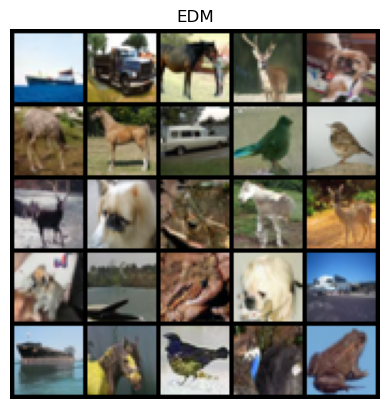

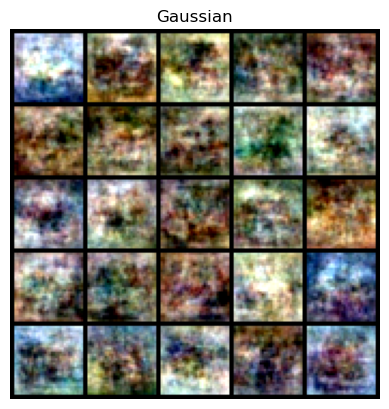

In [89]:
plt.imshow(tsr_to_mtg(x_out, nrow=5))
plt.axis('off')
plt.title("EDM")
plt.show()
plt.imshow(tsr_to_mtg(x_out_gauss, nrow=5))
plt.axis('off')
plt.title("Gaussian")
plt.show()

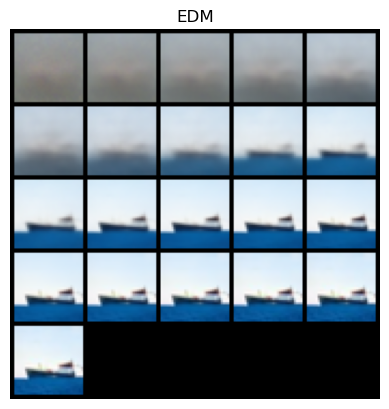

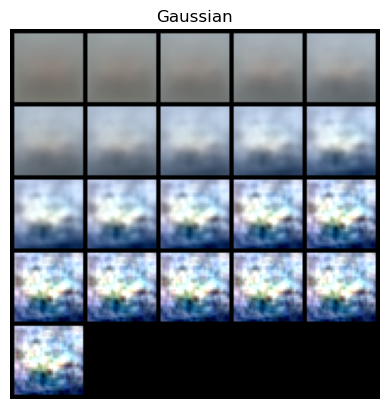

In [90]:
plt.imshow(tsr_to_mtg(denoised_traj[:,0], nrow=5))
plt.axis('off')
plt.title("EDM")
plt.show()
plt.imshow(tsr_to_mtg(denoised_traj_gauss[:,0], nrow=5))
plt.axis('off')
plt.title("Gaussian")
plt.show()